# Tiling into Chips

<!-- markdownlint-disable MD033-->
<div class="page-subtitle">
Splitting large rasters into paired image and mask tiles
</div>
<!-- markdownlint-enable MD033 -->

---

## 1. Motivation

A single satellite or aerial scene can span tens of thousands of pixels in each direction, while most deep learning models expect inputs of a few hundred pixels, commonly 256×256 or 512×512. Tiling, sometimes called "chipping," slices these large scenes into pieces that actually fit into GPU memory and match your model's expected input size.

---

## 2. Core idea

Tiling has two main parameters: **tile size**, the width and height of each chip, and **stride**, the step size between consecutive chips. When stride equals tile size, chips do not overlap; when stride is smaller, chips overlap.

Overlap is useful because objects near chip edges may otherwise be cut in half, which can confuse a model during training. The trade-off is that overlap creates more chips, uses more storage and takes more processing time.

---

## 3. Workflow

### A. Choose tile size and stride

Use tile size and stride as project parameters.

| Overlap | Stride for 256 px tiles | Stride for 512 px tiles | Typical use |
| --- | ---: | ---: | --- |
| 0% | 256 | 512 | Simple classification or large uniform areas. |
| 25% | 192 | 384 | General-purpose tiling with moderate boundary issues. |
| 50% | 128 | 256 | Dense objects, buildings or small features. |
| 75% | 64 | 128 | Maximum coverage, but many more chips. |

For a first project prototype, start simple. Use a small area and a moderate overlap (e.g. 25%) before scaling up.

```{tip}
Choose tile size and stride based on the object size and the model input size. A tile should contain enough context for the model to learn the feature, but not so much that small objects disappear.
```

### B. Generate tiles from one image

The `export_geotiff_tiles()` function can tile imagery, rasterise vector labels and save paired image-mask tiles in one workflow.

In [1]:
from pathlib import Path

import geoai

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

raster_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissimage_rgb_subset_05m.tif"
vector_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissbuildings3D_clip.geojson"

raster_path = geoai.download_file(
    raster_url, output_path=str(DATA_DIR / Path(raster_url).name)
)
vector_path = geoai.download_file(
    vector_url, output_path=str(DATA_DIR / Path(vector_url).name)
)

In [2]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

if not hasattr(cm, "get_cmap"):
    cm.get_cmap = plt.get_cmap

tiles = geoai.export_geotiff_tiles(
    in_raster=raster_path,
    out_folder="output",
    in_class_data=vector_path,
    tile_size=512,
    stride=384,
    buffer_radius=0,
    create_overview=True,
    quiet=True,
)

In this example:

- `tile_size=512` creates 512 × 512 pixel chips,
- `stride=384` creates 25% overlap,
- `create_overview=True` creates an overview image showing tile boundaries,
- `buffer_radius=0` means polygon labels are not expanded,
- `quiet=True` suppresses the function's per-tile progress output, so only the final result prints instead of a line for every chip generated.

### C. Inspect image-mask pairs

Before moving on, inspect the overview image and a handful of individual image/mask pairs to confirm that {term}`tiles <Tile>` were generated where you expect and that labels align correctly within each one.

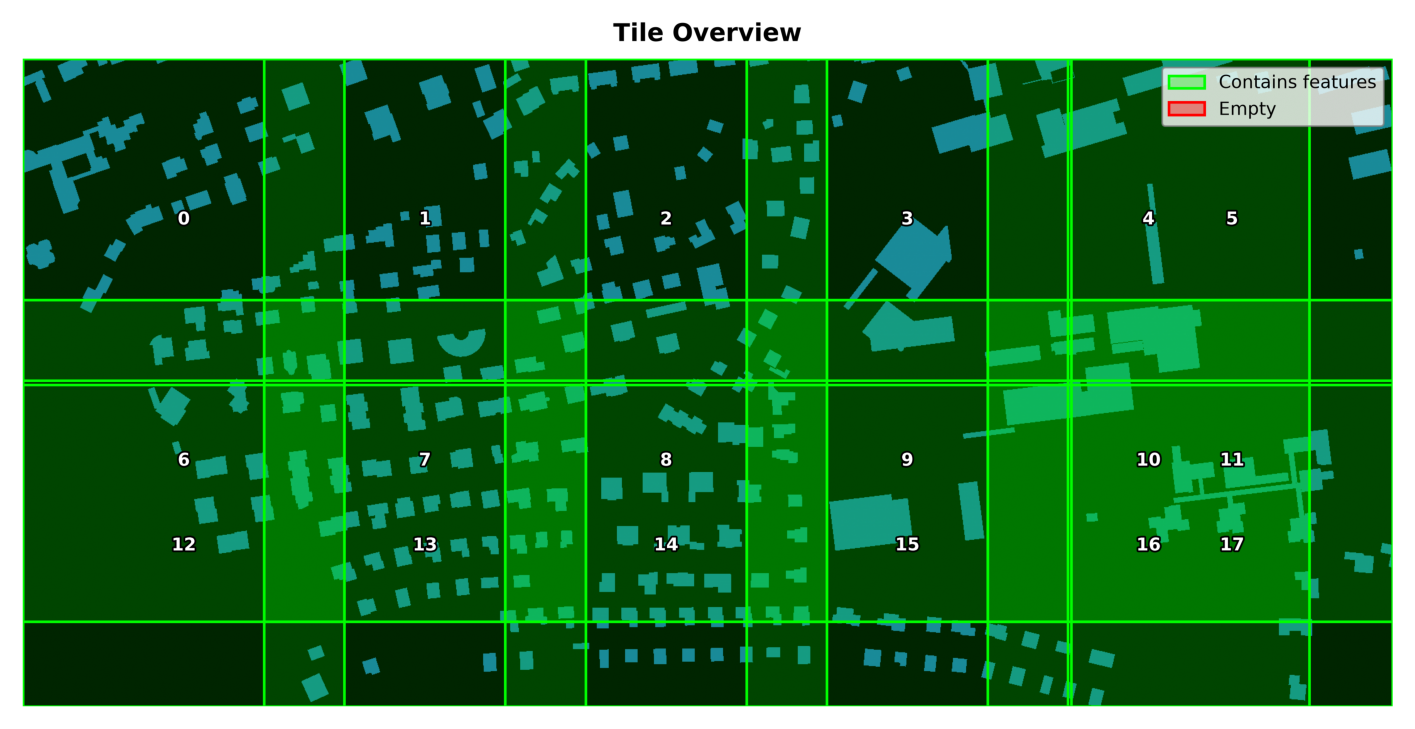

In [3]:
geoai.view_image("output/overview.png", figsize=(18, 10))

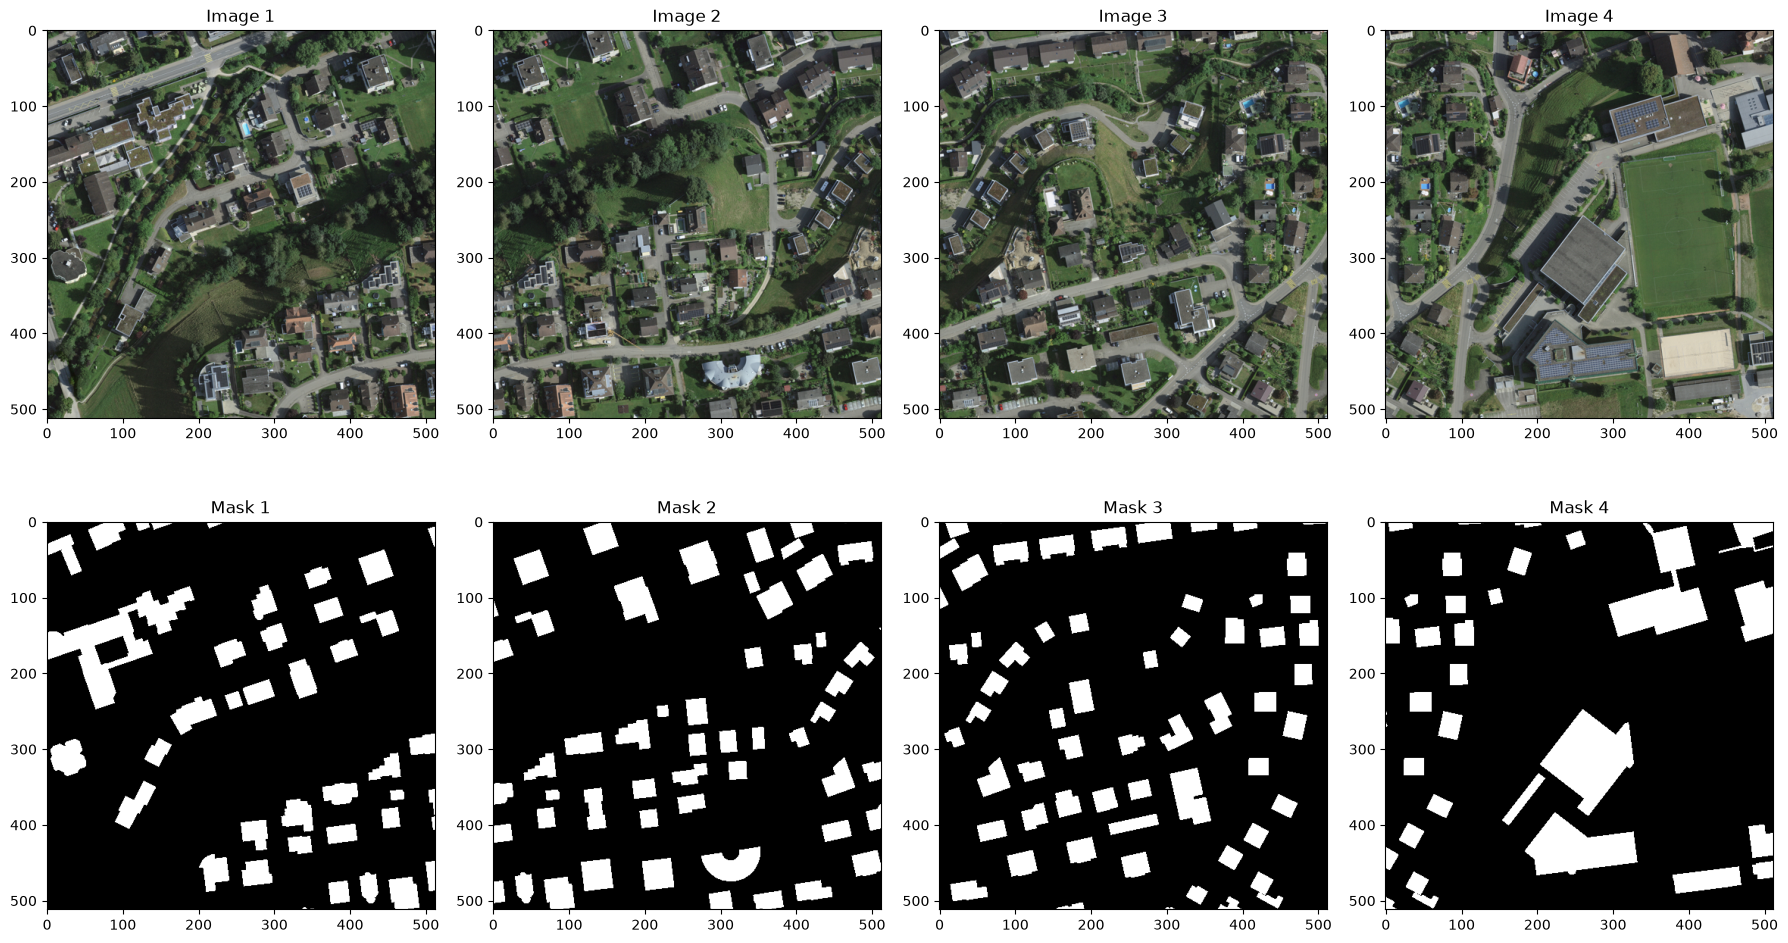

In [4]:
fig = geoai.display_training_tiles(
    output_dir="output",
    num_tiles=4,
    figsize=(18, 10),
)

```{admonition} Tile size is a modeling decision
:class: important
Your tile size should match the input size your chosen model architecture expects, and should be large enough to give the model useful spatial context around the objects you care about. Choosing it in isolation from your modeling plan is a common source of rework later.
```

---

## 4. Common pitfalls

| Pitfall | How to avoid it |
| --- | --- |
| Tile size is chosen randomly | Match it to model input size and feature size. |
| No overlap is used for boundary-sensitive objects | Use overlap when objects are often cut at tile edges. |
| Too much overlap creates too many files | Start with a small prototype and check chip count. |
| Overview image is ignored | Use it to check coverage and empty areas. |
| Image chips and masks do not match | Inspect several image-mask pairs before training. |
| Tiling parameters are not documented | Record tile size, stride, overlap and filtering choices. |

---

## 5. Mini task

Using your own image/mask pair (or the sample data here), generate tiles at two different overlap settings (for example, 0% and 50%) and compare the total tile counts.

:::{note} Sample solution
:class: dropdown

In [5]:
tiles_0 = geoai.export_geotiff_tiles(
    in_raster=raster_path,
    out_folder="output_0pct",
    in_class_data=vector_path,
    tile_size=256,
    stride=256,
    quiet=True,
)
tiles_50 = geoai.export_geotiff_tiles(
    in_raster=raster_path,
    out_folder="output_50pct",
    in_class_data=vector_path,
    tile_size=256,
    stride=128,
    quiet=True,
)

The 50% overlap setting produces roughly four times as many tiles as the 0% setting, for the same source image. Inspecting a few tiles near the image edges shows that, with 0% overlap, a handful of buildings are cut cleanly in half at tile boundaries, while with 50% overlap those same buildings appear whole in at least one neighboring tile.
:::

---

## 6. Key takeaways

- Tiling turns large rasters into model-ready image chips.
- {term}`Stride` controls overlap between neighbouring chips.
- Overlap helps with edge objects but increases storage and processing time.
- The overview image checks spatial coverage.
- Image-mask pair previews are a required quality check before training.

### Useful links

- [GeoAI Video Tutorial](https://youtu.be/9kuAVYgY_p8?si=4OnOSW7JZfIfecCf) - creating georeferenced image chips for deep learning